In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv("/content/drive/MyDrive/hospital ai agent/diabetic_data.csv")

# Show first 5 rows

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Shape of dataset

print("Dataset Shape:", df.shape)

# Column names

print("\nColumns:\n")
print(df.columns)

# Dataset information

print("\nDataset Info:\n")
print(df.info())

Dataset Shape: (101766, 50)

Columns:

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

Dataset Info:

<class 'pandas

In [ ]:
# Missing values

missing_values = df.isnull().sum()

print(missing_values)

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
# Remove duplicate rows

df = df.drop_duplicates()

# Fill missing values

df = df.fillna(method="ffill")

print("Data cleaned successfully")

/tmp/ipykernel_591/4195573478.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


Data cleaned successfully


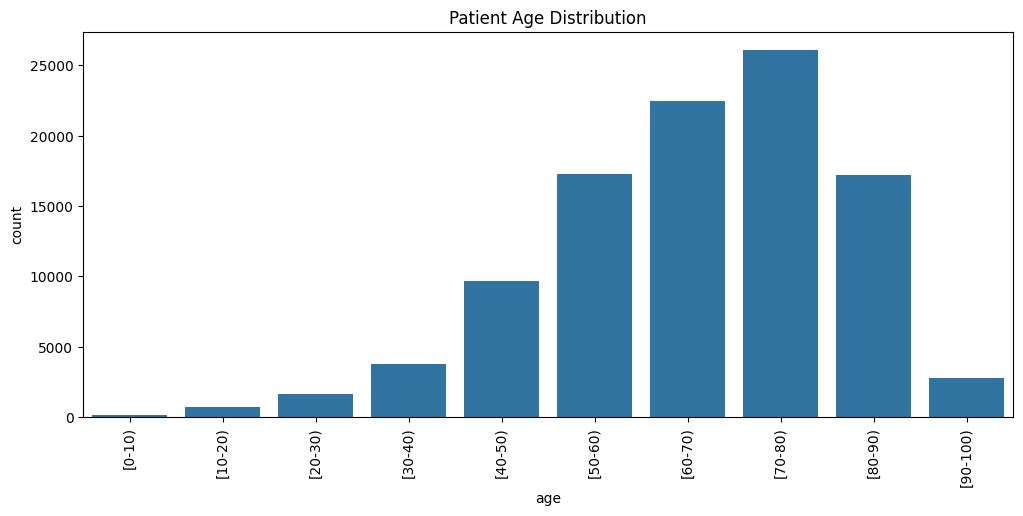

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(x='age', data=df)

plt.title("Patient Age Distribution")
plt.xticks(rotation=90)

plt.show()

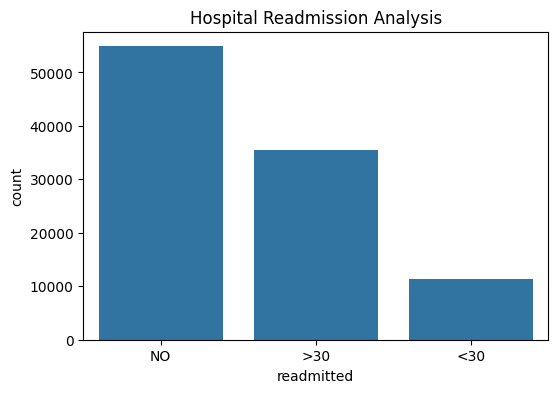

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='readmitted', data=df)

plt.title("Hospital Readmission Analysis")

plt.show()

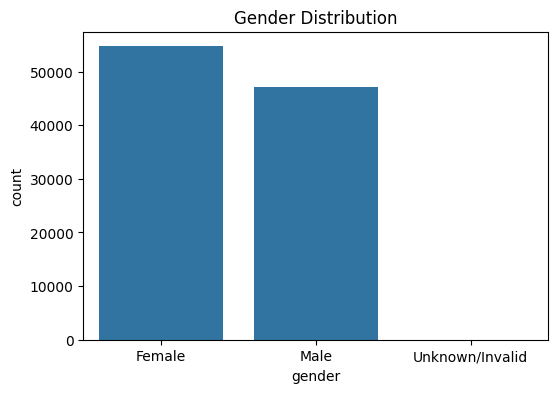

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")

plt.show()

# Business Problem

Hospitals often struggle to identify high-risk patients early, leading to delayed treatment, increased readmissions, and resource overload.

This project aims to build an AI-powered healthcare intelligence platform capable of analyzing patient records, predicting readmission risks, and supporting clinical decision-making.

# Phase 2 — AI Risk Prediction Engine

In this phase, we build a machine learning system to predict hospital readmission risks using patient healthcare records.

In [ ]:
# Unique target values

print(df['readmitted'].unique())

['NO' '>30' '<30']


In [ ]:
# Convert target into binary

df['readmitted'] = df['readmitted'].replace({
    'NO': 0,
    '>30': 1,
    '<30': 1
})

print(df['readmitted'].value_counts())

readmitted
0    54864
1    46902
Name: count, dtype: int64


/tmp/ipykernel_591/2069711304.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({


In [ ]:
# Remove unnecessary columns

remove_cols = ['encounter_id', 'patient_nbr']

for col in remove_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("Columns removed successfully")

Columns removed successfully


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col].astype(str))

print("Encoding completed")

Encoding completed


In [ ]:
# Features

X = df.drop('readmitted', axis=1)

# Target

y = df['readmitted']

print(X.shape)
print(y.shape)

(101766, 47)
(101766,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (81412, 47)
Testing data: (20354, 47)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
# Predictions

predictions = model.predict(X_test)

print(predictions[:10])

[0 0 1 1 0 0 0 1 0 1]


In [ ]:
from sklearn.metrics import accuracy_score

# Accuracy

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.6389898791392356


In [ ]:
from sklearn.metrics import classification_report

# Report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.64      0.74      0.69     10952
           1       0.63      0.52      0.57      9402

    accuracy                           0.64     20354
   macro avg       0.64      0.63      0.63     20354
weighted avg       0.64      0.64      0.63     20354



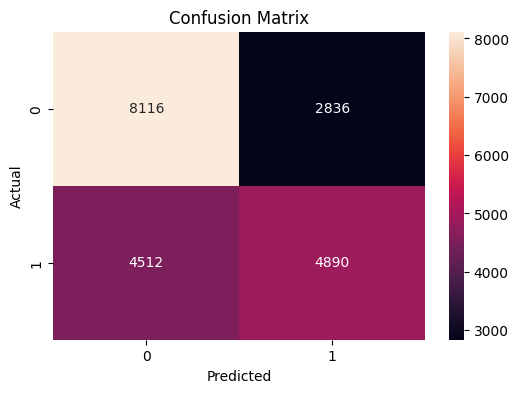

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Feature importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                     Feature  Importance
10        num_lab_procedures    0.083248
16                    diag_1    0.079220
17                    diag_2    0.078219
18                    diag_3    0.076502
12           num_medications    0.072384
7           time_in_hospital    0.051514
15          number_inpatient    0.050979
2                        age    0.043569
5   discharge_disposition_id    0.040258
9          medical_specialty    0.038318


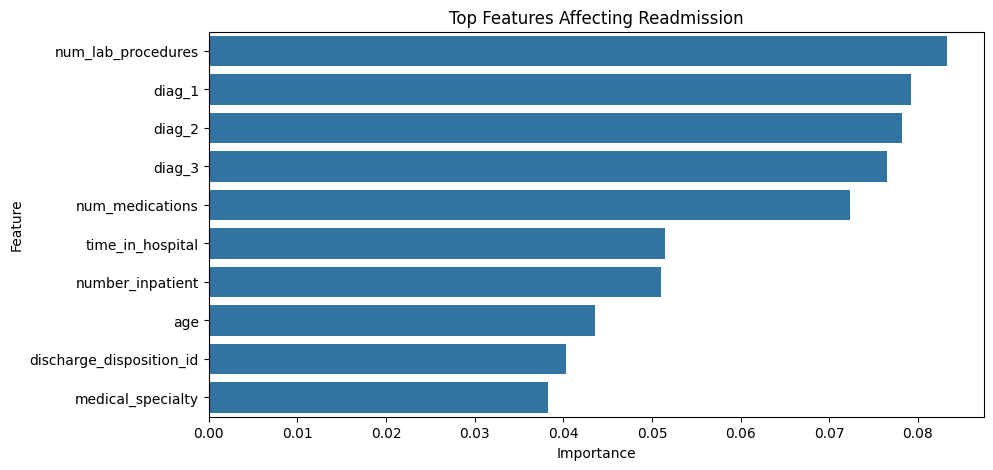

In [ ]:
# Top 10 important features

top_features = importance.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Features Affecting Readmission")

plt.show()

# Clinical Insights

The machine learning model identified important factors contributing to hospital readmission risk.

Key influencing factors included:
- Number of prior admissions
- Time spent in hospital
- Medication changes
- Diabetes severity indicators
- Age group

Such predictive systems can support hospitals in identifying high-risk patients early and improving treatment prioritization.

In [ ]:
import joblib

In [ ]:
joblib.dump(
    model,
    "hospital_readmission_model.pkl"
)

print("Model saved successfully")

Model saved successfully
